# Modeling: Stent Thrombosis Prediction (VLST)

## Overview

This notebook trains and evaluates binary classifiers to predict **Stent thrombosis** using the preprocessed data from `preprocessing.ipynb`. We use:

- **Data**: Preprocessed train/test arrays from `../data/processed/`
- **Models**: Logistic Regression, Decision Tree, Random Forest, Gaussian NB, CatBoost, XGBoost, LightGBM (with **GridSearchCV** where applicable)
- **Flowcharts**: Fitted GridSearchCV/pipeline objects are displayed so Jupyter shows the interactive sklearn pipeline diagram (expandable flowchart)
- **Imbalance**: Class weights in models, optional **SMOTE** on the training set (see §2), and metrics suited to imbalanced data (ROC-AUC, PR-AUC, F1, recall)
- **Artifacts**: Best models and results saved to `../data/result/modeling/`

## 1. Setup and Load Preprocessed Data

In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import warnings
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

PROCESSED_DIR = "../data/processed"
RESULT_DIR = "../data/result/modeling"
os.makedirs(RESULT_DIR, exist_ok=True)

# Load preprocessed data (from preprocessing.ipynb)
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
feature_names = pd.read_csv(os.path.join(PROCESSED_DIR, "feature_names.csv"))[
    "feature_name"
].tolist()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {len(feature_names)}")
print(f"Train target: 0={np.sum(y_train == 0)}, 1={np.sum(y_train == 1)}")
print(f"Test target:  0={np.sum(y_test == 0)}, 1={np.sum(y_test == 1)}")

Train: (4148, 174), Test: (1037, 174)
Features: 174
Train target: 0=4074, 1=74
Test target:  0=1019, 1=18


## 2a. Addressing Class Imbalance (Optional SMOTE)

As noted in **preprocessing.ipynb**, the target is strongly imbalanced. We use **class weights** in the models below and optionally apply **SMOTE** to the **training set only** (test set unchanged). Set `USE_SMOTE = False` to use the original training set.

In [3]:
from imblearn.over_sampling import SMOTE

USE_SMOTE = (
    True  # Set to False to train on original (imbalanced) data with class weights only
)

if USE_SMOTE:
    n_minority = (y_train == 1).sum()
    k = min(5, n_minority - 1) if n_minority > 1 else 1
    if k < 1:
        print("SMOTE skipped: minority class has too few samples.")
    else:
        smote = SMOTE(random_state=42, k_neighbors=k)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print(
            f"SMOTE applied: train size -> {X_train.shape[0]} (0={np.sum(y_train == 0)}, 1={np.sum(y_train == 1)})"
        )
else:
    print("Using original (imbalanced) training set with class weights in models.")

SMOTE applied: train size -> 8148 (0=4074, 1=4074)


## 2. Cross-Validation and Evaluation Helpers

We use stratified 5-fold CV in GridSearchCV and define a small helper to compute metrics and optionally plot ROC/PR curves.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model(name, model, X_te=X_test, y_te=y_test):
    """Print metrics and return dict of test metrics."""
    y_pred = model.predict(X_te)
    y_prob = (
        model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    )
    out = {
        "model": name,
        "accuracy": (y_pred == y_te).mean(),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "precision": precision_score(y_te, y_pred, zero_division=0),
    }
    if y_prob is not None:
        out["roc_auc"] = roc_auc_score(y_te, y_prob)
        out["pr_auc"] = average_precision_score(y_te, y_prob)
    print(classification_report(y_te, y_pred))
    print("ROC-AUC:", out.get("roc_auc"), "| PR-AUC:", out.get("pr_auc"))
    return out

## 3. Logistic Regression + GridSearchCV

We tune regularization (C, penalty) and use **class_weight='balanced'** for the imbalanced target. After fitting, displaying the GridSearchCV object shows the pipeline flowchart in Jupyter.

In [5]:
param_grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l2", "l1"],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [2000],
}
# For L1 use solver='liblinear' and penalty='l1' (or l1_ratio=1 with 'saga')

grid_lr = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", random_state=42),
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid_lr.fit(X_train, y_train)
print("Best params:", grid_lr.best_params_)
print("Best CV F1:", round(grid_lr.best_score_, 4))

Best params: {'C': 1.0, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1: 0.9923


In [6]:
# Display fitted GridSearchCV (flowchart of the best pipeline in Jupyter)
display(grid_lr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [2000], 'penalty': ['l2', 'l1'], 'solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [7]:
best_lr = grid_lr.best_estimator_
results_list = [evaluate_model("LogisticRegression", best_lr)]

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1019
           1       0.53      1.00      0.69        18

    accuracy                           0.98      1037
   macro avg       0.76      0.99      0.84      1037
weighted avg       0.99      0.98      0.99      1037

ROC-AUC: 0.9989641260495038 | PR-AUC: 0.957530864197531


### 3.1 Logistic Regression – CV results (top 5 by F1)

View GridSearchCV `cv_results_` to see how different hyperparameters performed.

In [8]:
cv_res_lr = pd.DataFrame(grid_lr.cv_results_)
cols = [
    c for c in cv_res_lr.columns if c.startswith("param_") or c == "mean_test_score"
]
display(cv_res_lr[cols].sort_values("mean_test_score", ascending=False).head())

,param_C,param_max_iter,param_penalty,param_solver,mean_test_score
11,1.0,2000,l1,liblinear,0.992330
8,1.0,2000,l2,lbfgs,0.991607
4,0.1,2000,l2,lbfgs,0.991362
12,10.0,2000,l2,lbfgs,0.991247
15,10.0,2000,l1,liblinear,0.991132


## 4. Decision Tree + GridSearchCV

Tune tree depth, min_samples_split, min_samples_leaf, and criterion. After fitting, display the grid to see the pipeline flowchart.

In [9]:
param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid_dt.fit(X_train, y_train)
print("Best params:", grid_dt.best_params_)
print("Best CV F1:", round(grid_dt.best_score_, 4))

Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1: 0.9947


In [10]:
# Display fitted GridSearchCV (flowchart)
display(grid_dt)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [11]:
best_dt = grid_dt.best_estimator_
results_list.append(evaluate_model("DecisionTree", best_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1019
           1       0.77      0.94      0.85        18

    accuracy                           0.99      1037
   macro avg       0.89      0.97      0.92      1037
weighted avg       1.00      0.99      0.99      1037

ROC-AUC: 0.9695780176643769 | PR-AUC: 0.730762299952271


### 4.1 Decision Tree: Visualize the Fitted Tree

Plot the best decision tree (limited depth for readability). Feature names from preprocessing are used for labels.

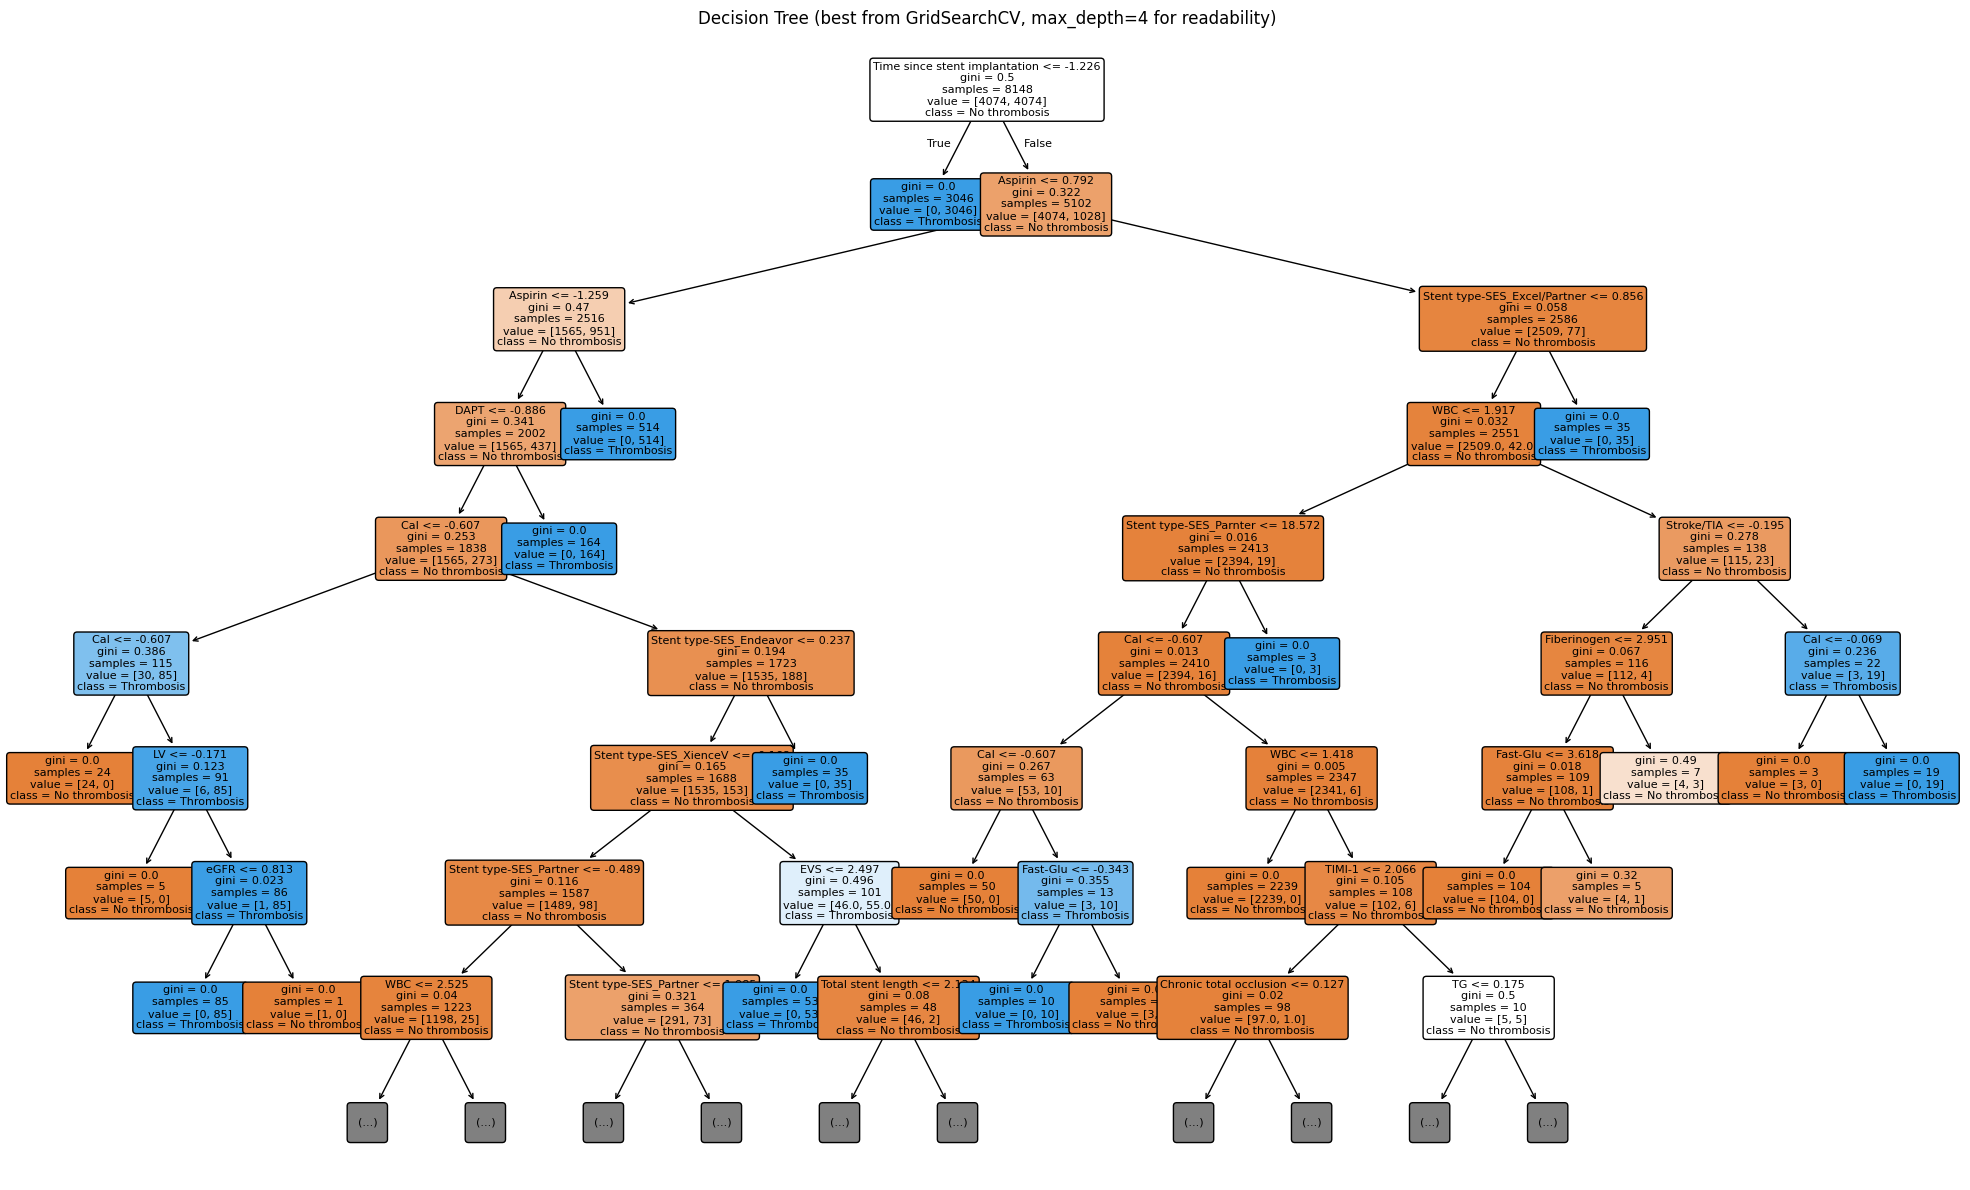

Saved: decision_tree_plot.png


In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(
    best_dt,
    max_depth=8,
    feature_names=feature_names,
    class_names=["No thrombosis", "Thrombosis"],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8,
)
ax.set_title("Decision Tree (best from GridSearchCV, max_depth=4 for readability)")
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, "decision_tree_plot.png"), dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: decision_tree_plot.png")

## 5. Random Forest + GridSearchCV

Tune n_estimators, max_depth, and min_samples_leaf. Display the fitted grid for the pipeline flowchart.

In [16]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 2, 5],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid_rf.fit(X_train, y_train)
print("Best params:", grid_rf.best_params_)
print("Best CV F1:", round(grid_rf.best_score_, 4))

Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1: 0.9991


In [19]:
# Display fitted GridSearchCV (flowchart)
display(grid_rf)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [20]:
best_rf = grid_rf.best_estimator_
results_list.append(evaluate_model("RandomForest", best_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1019
           1       1.00      0.67      0.80        18

    accuracy                           0.99      1037
   macro avg       1.00      0.83      0.90      1037
weighted avg       0.99      0.99      0.99      1037

ROC-AUC: 0.9992912441391342 | PR-AUC: 0.96795116194626


## 5b. Gaussian Naive Bayes + GridSearchCV

Gaussian NB is fast and works well with balanced or moderately imbalanced data. We tune `var_smoothing` for stability.

In [21]:
param_grid_gnb = {"var_smoothing": np.logspace(-12, -8, 10)}

grid_gnb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_gnb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_gnb.fit(X_train, y_train)
print("Best params:", grid_gnb.best_params_)
print("Best CV F1:", round(grid_gnb.best_score_, 4))

Best params: {'var_smoothing': np.float64(1e-12)}
Best CV F1: 0.7038


In [22]:
display(grid_gnb)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-08])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [23]:
best_gnb = grid_gnb.best_estimator_
results_list.append(evaluate_model("GaussianNB", best_gnb))

              precision    recall  f1-score   support

           0       1.00      0.17      0.29      1019
           1       0.02      1.00      0.04        18

    accuracy                           0.19      1037
   macro avg       0.51      0.59      0.17      1037
weighted avg       0.98      0.19      0.29      1037

ROC-AUC: 0.585377821393523 | PR-AUC: 0.02085747392815759


## 5c. CatBoost + GridSearchCV

CatBoost handles categorical features natively; here we use the preprocessed numeric matrix.

In [24]:
# Wrapper so CatBoost works with GridSearchCV
class CatBoostClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.catboost_ = CatBoostClassifier(**kwargs)

    def get_params(self, deep=True):
        return self.catboost_.get_params(deep=deep)

    def set_params(self, **params):
        self.catboost_.set_params(**params)
        return self

    def fit(self, X, y, **fit_params):
        self.catboost_.fit(X, y, **fit_params)
        return self

    def predict(self, X):
        return self.catboost_.predict(X)

    def predict_proba(self, X):
        return self.catboost_.predict_proba(X)

In [25]:
param_grid_cat = {
    "depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "iterations": [100, 200],
    "l2_leaf_reg": [1, 3],
}
grid_cat = GridSearchCV(
    estimator=CatBoostClassifierWrapper(
        random_state=42,
        verbose=0,
        auto_class_weights="Balanced",
    ),
    param_grid=param_grid_cat,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_cat.fit(X_train, y_train)
print("Best params:", grid_cat.best_params_)
print("Best CV F1:", round(grid_cat.best_score_, 4))
best_cat = grid_cat.best_estimator_
display(grid_cat)
results_list.append(evaluate_model("CatBoost", best_cat))

Best params: {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV F1: 0.9999


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass... verbose=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [100, 200], 'l2_leaf_reg': [1, 3], 'learning_rate': [0.05, 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1019
           1       1.00      0.89      0.94        18

    accuracy                           1.00      1037
   macro avg       1.00      0.94      0.97      1037
weighted avg       1.00      1.00      1.00      1037

ROC-AUC: 0.9995093228655544 | PR-AUC: 0.9773406947319991


## 5d. XGBoost + GridSearchCV

Gradient boosting; often strong on tabular data.

In [26]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
param_grid_xgb = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "min_child_weight": [1, 3],
}
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
    ),
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_xgb.fit(X_train, y_train)
print("Best params:", grid_xgb.best_params_)
print("Best CV F1:", round(grid_xgb.best_score_, 4))
best_xgb = grid_xgb.best_estimator_
display(grid_xgb)
results_list.append(evaluate_model("XGBoost", best_xgb))

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200}
Best CV F1: 0.9994


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1019
           1       1.00      0.89      0.94        18

    accuracy                           1.00      1037
   macro avg       1.00      0.94      0.97      1037
weighted avg       1.00      1.00      1.00      1037

ROC-AUC: 0.9987460473230837 | PR-AUC: 0.9608894608894609


## 5e. LightGBM + GridSearchCV

LightGBM is fast and often performs well on tabular data.

In [27]:
param_grid_lgb = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "min_child_samples": [10, 20],
}
grid_lgb = GridSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        class_weight="balanced",
        verbosity=-1,
    ),
    param_grid=param_grid_lgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_lgb.fit(X_train, y_train)
print("Best params:", grid_lgb.best_params_)
print("Best CV F1:", round(grid_lgb.best_score_, 4))
best_lgb = grid_lgb.best_estimator_
display(grid_lgb)
results_list.append(evaluate_model("LightGBM", best_lgb))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 200}
Best CV F1: 0.9994


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1019
           1       1.00      0.89      0.94        18

    accuracy                           1.00      1037
   macro avg       1.00      0.94      0.97      1037
weighted avg       1.00      1.00      1.00      1037

ROC-AUC: 0.9989096063678988 | PR-AUC: 0.9707602339181287


## 6. ROC and Precision-Recall Curves

Compare all three models on ROC and PR curves (PR is more informative for imbalanced data).

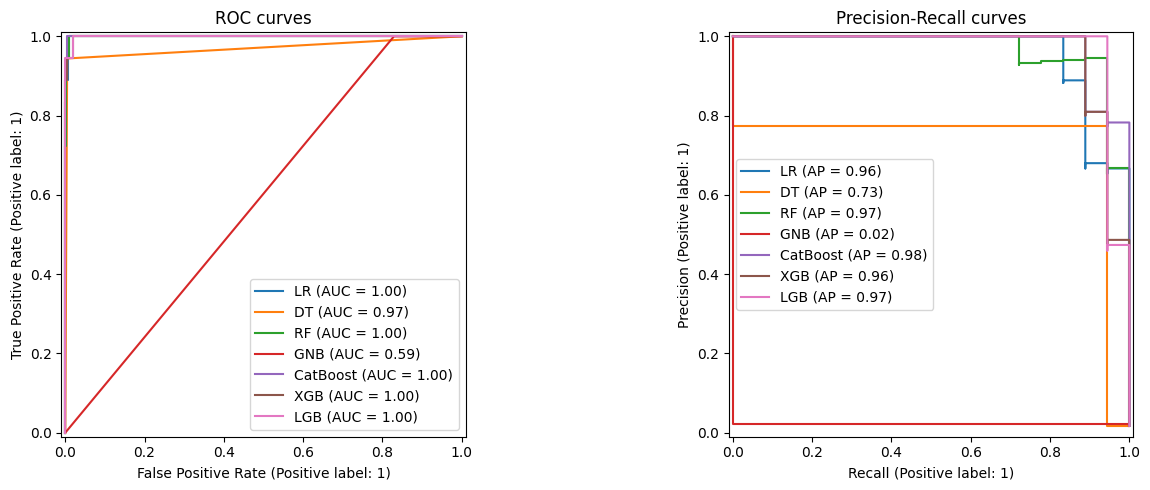

Saved: roc_pr_curves.png


In [29]:
curve_models = [
    ("LR", best_lr),
    ("DT", best_dt),
    ("RF", best_rf),
    ("GNB", best_gnb),
    ("CatBoost", best_cat),
    ("XGB", best_xgb),
    ("LGB", best_lgb),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model in curve_models:
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name=name)
axes[0].set_title("ROC curves")
axes[0].legend()

for name, model in curve_models:
    y_prob = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=name)
axes[1].set_title("Precision-Recall curves")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "roc_pr_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_pr_curves.png")

## 7. Confusion Matrices

Heatmaps of confusion matrices for each model on the test set.

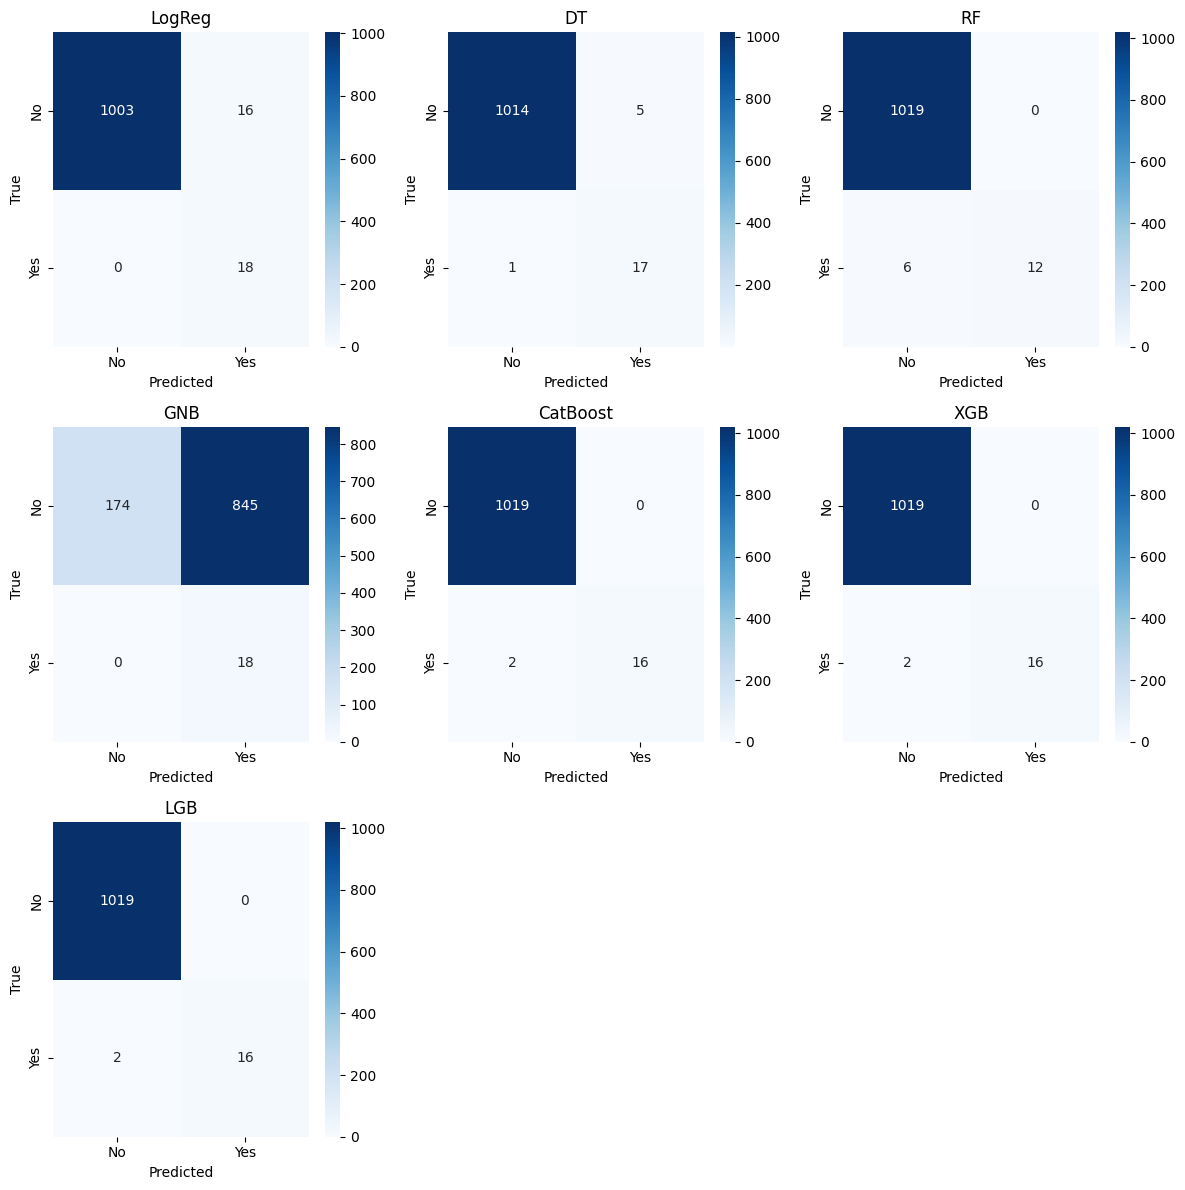

Saved: confusion_matrices.png


In [30]:
import seaborn as sns

cm_models = [
    ("LogReg", best_lr),
    ("DT", best_dt),
    ("RF", best_rf),
    ("GNB", best_gnb),
    ("CatBoost", best_cat),
    ("XGB", best_xgb),
    ("LGB", best_lgb),
]
n_models = len(cm_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_models > 1 else [axes]
for ax, (name, model) in zip(axes, cm_models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
    )
    ax.set_title(name)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
for ax in axes[len(cm_models) :]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: confusion_matrices.png")

## 8. Threshold Analysis (Optional)

For the best model by F1, we can sweep the decision threshold and report precision, recall, and F1. This helps choose a threshold if you want to favor recall over precision or vice versa.

In [31]:
# Pick best model by test F1 for threshold analysis
threshold_candidates = [
    ("LR", best_lr),
    ("DT", best_dt),
    ("RF", best_rf),
    ("GNB", best_gnb),
    ("CatBoost", best_cat),
    ("XGB", best_xgb),
    ("LGB", best_lgb),
]
best_by_f1 = max(
    threshold_candidates, key=lambda t: f1_score(y_test, t[1].predict(X_test))
)
name_best, model_best = best_by_f1
y_prob_best = model_best.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
rows = []
for t in thresholds:
    y_pt = (y_prob_best >= t).astype(int)
    rows.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, y_pt, zero_division=0),
            "recall": recall_score(y_test, y_pt, zero_division=0),
            "f1": f1_score(y_test, y_pt, zero_division=0),
        }
    )
threshold_df = pd.DataFrame(rows)
print(f"Threshold analysis for best model ({name_best}):")
display(threshold_df)

Threshold analysis for best model (CatBoost):


,threshold,precision,recall,f1
0,0.10,0.888889,0.888889,0.888889
1,0.15,0.941176,0.888889,0.914286
2,0.20,1.000000,0.888889,0.941176
3,0.25,1.000000,0.888889,0.941176
4,0.30,1.000000,0.888889,0.941176
5,0.35,1.000000,0.888889,0.941176
6,0.40,1.000000,0.888889,0.941176
7,0.45,1.000000,0.888889,0.941176
8,0.50,1.000000,0.888889,0.941176
9,0.55,1.000000,0.888889,0.941176


## 9. Results Summary and Saving Artifacts

Summarize test metrics for all models and save best estimators and results table.

In [32]:
results_df = pd.DataFrame(results_list)
results_df = results_df.reindex(
    columns=["model", "accuracy", "f1", "recall", "precision", "roc_auc", "pr_auc"]
)
print("Test set metrics:")
display(results_df)

results_df.to_csv(os.path.join(RESULT_DIR, "test_metrics.csv"), index=False)
threshold_df.to_csv(os.path.join(RESULT_DIR, "threshold_analysis.csv"), index=False)

joblib.dump(best_lr, os.path.join(RESULT_DIR, "best_logistic.joblib"))
joblib.dump(best_dt, os.path.join(RESULT_DIR, "best_decision_tree.joblib"))
joblib.dump(best_rf, os.path.join(RESULT_DIR, "best_random_forest.joblib"))
joblib.dump(best_gnb, os.path.join(RESULT_DIR, "best_gaussian_nb.joblib"))
joblib.dump(best_cat, os.path.join(RESULT_DIR, "best_catboost.joblib"))
joblib.dump(best_xgb, os.path.join(RESULT_DIR, "best_xgboost.joblib"))
joblib.dump(best_lgb, os.path.join(RESULT_DIR, "best_lightgbm.joblib"))

print("\nSaved to", RESULT_DIR)
for f in sorted(os.listdir(RESULT_DIR)):
    print(" ", f)

Test set metrics:


,model,accuracy,f1,recall,precision,roc_auc,pr_auc
0,LogisticRegression,0.984571,0.692308,1.000000,0.529412,0.998964,0.957531
1,DecisionTree,0.994214,0.850000,0.944444,0.772727,0.969578,0.730762
2,RandomForest,0.994214,0.800000,0.666667,1.000000,0.999291,0.967951
3,RandomForest,0.994214,0.800000,0.666667,1.000000,0.999291,0.967951
4,RandomForest,0.994214,0.800000,0.666667,1.000000,0.999291,0.967951
5,GaussianNB,0.185149,0.040863,1.000000,0.020857,0.585378,0.020857
6,CatBoost,0.998071,0.941176,0.888889,1.000000,0.999509,0.977341
7,XGBoost,0.998071,0.941176,0.888889,1.000000,0.998746,0.960889
8,LightGBM,0.998071,0.941176,0.888889,1.000000,0.998910,0.970760



Saved to ../data/result/modeling
  best_catboost.joblib
  best_decision_tree.joblib
  best_gaussian_nb.joblib
  best_lightgbm.joblib
  best_logistic.joblib
  best_random_forest.joblib
  best_xgboost.joblib
  confusion_matrices.png
  decision_tree_plot.png
  roc_pr_curves.png
  test_metrics.csv
  threshold_analysis.csv


## 10. Summary

- **Data**: Loaded from `../data/processed/` (preprocessing.ipynb).
- **Models**: Logistic Regression, Decision Tree, Random Forest, Gaussian NB, CatBoost, XGBoost, LightGBM (with **GridSearchCV** where applicable); each fitted grid is **displayed** so Jupyter shows the pipeline flowchart.
- **Imbalance**: `class_weight='balanced'` (and scale_pos_weight / auto_class_weights where supported), optional SMOTE on training data, and metrics: F1, ROC-AUC, PR-AUC, recall.
- **Visuals**: Decision tree plot, ROC/PR curves, confusion matrices, threshold table.
- **Artifacts**: Best estimators and metrics saved under `../data/result/modeling/`.

For inference on new data: preprocess with `preprocessor.joblib` and `scaler.joblib` from preprocessing, then call `best_*.predict(X)` or `best_*.predict_proba(X)`.

# Why are the model metrics so incredibly good and high (Why are the models overly accurate? Is there data leakage?)

Here’s what the code and data show.

## 1. The pipeline is not “leaking” in the usual ML sense

From `preprocessing.ipynb`:

- `train_test_split` is stratified, then **only** `X_train` is used to `fit` the `ColumnTransformer` and `StandardScaler`; `X_test` is only `transform`ed.
- `y_train` / `y_test` are aligned with the same split.

So there is **no** bug like: scaling on full data, fitting on test, or shuffled rows between `X` and `y`.

`evaluate_model` uses `X_test` and `y_test` consistently. The CatBoost wrapper’s `fit` / `predict` / `predict_proba` wiring is normal.

---

## 2. Why metrics look “impossible” anyway: **feature–label leakage**, not a code bug

The problem is **what** “Time since stent implantation” means for **class 0 vs class 1** in this file.

On the full raw data:

| Class | `Time since stent implantation` |
|--------|----------------------------------|
| **0 (no thrombosis)** | **min = 1241**, max = 1605 (all values ≥ 1241) |
| **1 (thrombosis)** | **min = 380**, includes many values **&lt; 1241** |

So:

- **Every** control has time ≥ **1241** days.
- **Many** cases have time **&lt; 1241** days.

A single rule **“if time &lt; 1241 → predict thrombosis”** already gives:

- **0** false positives among controls (no control has time &lt; 1241),
- **~99.6% accuracy** on the full dataset,
- and a **very high** ROC-AUC (because time almost separates the groups).

That matches what you see with CatBoost: **0.9999 CV F1**, **~1.0 ROC-AUC**, **precision 1.0 for class 0** on the test set — the model can rely on (or amplify) this signal.

**Interpretation (substance, not sklearn):**  
For **non-events**, “time since stent implantation” behaves like a **narrow follow-up window** (everyone without an event lands in a high band). For **events**, it behaves like **time from implant to thrombosis**, which can be shorter. So the column is **not** a clean “baseline predictor of VLST”; it **mixes different time definitions** for cases vs controls. That is **structural / temporal leakage**: the label is partly encoded in how the variable is defined.

Univariate checks also show **“Time since stent implantation”** as by far the strongest signal (e.g. very high univariate AUC on a test split). So the inflated metrics are **not** mysterious once you look at this column.

---

## 3. What to do for a **fair** prediction task

1. **Drop** `Time since stent implantation` (and any other variables that are **only comparable** if defined the same way for cases and controls), then re-run preprocessing and modeling.
2. Or **redefine** the variable so it is **time from implant to a common landmark** (e.g. index procedure date, or end of follow-up) for **both** groups, with the same definition for everyone.
3. If the scientific question is **when** thrombosis occurs, use **survival / time-to-event** methods instead of a single binary classifier with a time that is not a pure risk factor.

---

**Bottom line:** There is **no evidence of a bug** in the train/test or preprocessing code that would explain 0.9999. The explanation is **data leakage through `Time since stent implantation`** (and possibly other time-related fields), not incorrect sklearn usage. Dropping or fixing that variable will bring metrics down to something more interpretable for real risk prediction.